In [119]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.ticker import StrMethodFormatter, NullFormatter, ScalarFormatter, LogLocator
import pandas as pd
import seaborn as sb
import seaborn.objects as so

In [120]:
nnzs = pd.read_csv("../results/NEON-CPU.csv")
df = pd.read_csv("variations_gpu.csv", skip_blank_lines=True)
cpu = pd.read_csv("variations_cpu_polyester.csv", skip_blank_lines=True)
serial = pd.read_csv("variations_serial.csv", skip_blank_lines=True)

def insertnnz(df):
    df["cells"] = df["case_long"].apply(lambda x: int(x.split("-")[1]))
    c = sorted(df["cells"].unique())
    n = sorted(nnzs["nnz"].unique())
    d = {cc: nn for cc,nn in zip(c,n)}
    df["nnz"] = df["cells"].apply(lambda x: d[x] )
    return df
df = insertnnz(df)
cpu = insertnnz(cpu)
serial = insertnnz(serial)

In [121]:
S = {
    "faceBased": "Face-Based",
    "globalFaceBased": "Face-Based Global",
    "cellBased" : "Cell-Based",
    "batchedFace" : "Face-Based Batched"
}
M= {
    "PrecalculatedWeightsUpwind": "Upwind (Prec.)",
    "PrecalculatedWeightsCDF": "Linear (Prec.)",
    "DynamicUpwind": "Upwind (Dyn.)",
    "DynamicCDF": "Linear (Dyn.)",
    "HardCodedCDF": "Linear (Stat.)",
    "HardCodedUpwind": "Upwind (Stat.)",
    "FusedDivLap": "Fused",
    "Fused": "Fused"
}
T= {
    "PrecalculatedWeightsUpwind": "Precalculated Weights",
    "PrecalculatedWeightsCDF": "Precalculated Weights",
    "DynamicUpwind": "Dynamic",
    "DynamicCDF": "Dynamic",
    "HardCodedCDF": "Hardcoded",
    "HardCodedUpwind": "Hardcoded",
    "FusedDivLap": "Fused",
    "Fused": "Fused"
}
O= sorted(list(M.values()))
sorted_variants = O

def setup(df):
    df["s_display"] = df["strategy"].apply(lambda x : S[x])
    df["ms_normed"] = df["time_mean_ms"] / df["cells"]
    df["ns_normed"] = df["ms_normed"]* 1000000

    df["varDisplay"] = df["variant"].apply(lambda x : M[x])
    df["varType"] = df["variant"].apply(lambda x : T[x])
    df["bandwidth"] = df["nnz"] * 8  / (df["time_mean_ms"] * 1000000) 
    return df
cpu = setup(cpu)
df = setup(df)
serial = setup(serial)

def add_cpu_speedup(cpu_df, serial_df):
    baseline_cols = ["cells", "strategy", "variant"]
    serial_baseline = (
        serial_df
        .groupby(baseline_cols, as_index=False)["time_mean_ms"]
        .mean()
        .rename(columns={"time_mean_ms": "baseline_time_mean_ms"})
    )
    batched_baseline = (
        cpu_df[(cpu_df["strategy"] == "batchedFace") & (cpu_df["Threads"] == 2)]
        .groupby(baseline_cols, as_index=False)["time_mean_ms"]
        .mean()
        .rename(columns={"time_mean_ms": "baseline_time_mean_ms"})
    )
    baseline = pd.concat([serial_baseline, batched_baseline], ignore_index=True)
    out = cpu_df.merge(baseline, on=baseline_cols, how="left")
    out["speedup"] = out["baseline_time_mean_ms"] / out["time_mean_ms"]
    return out.drop(columns="baseline_time_mean_ms")

cpu = add_cpu_speedup(cpu, serial)


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

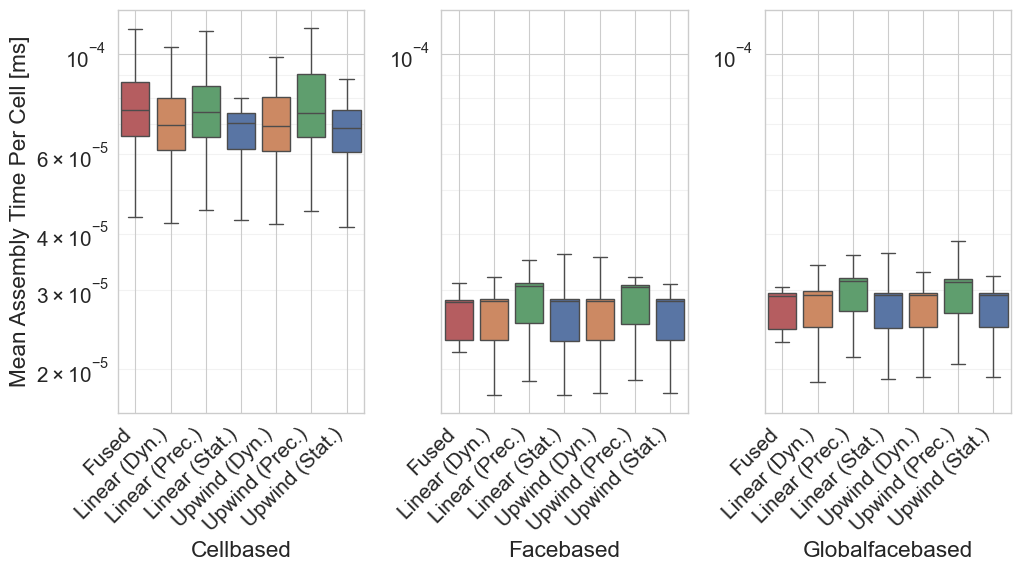

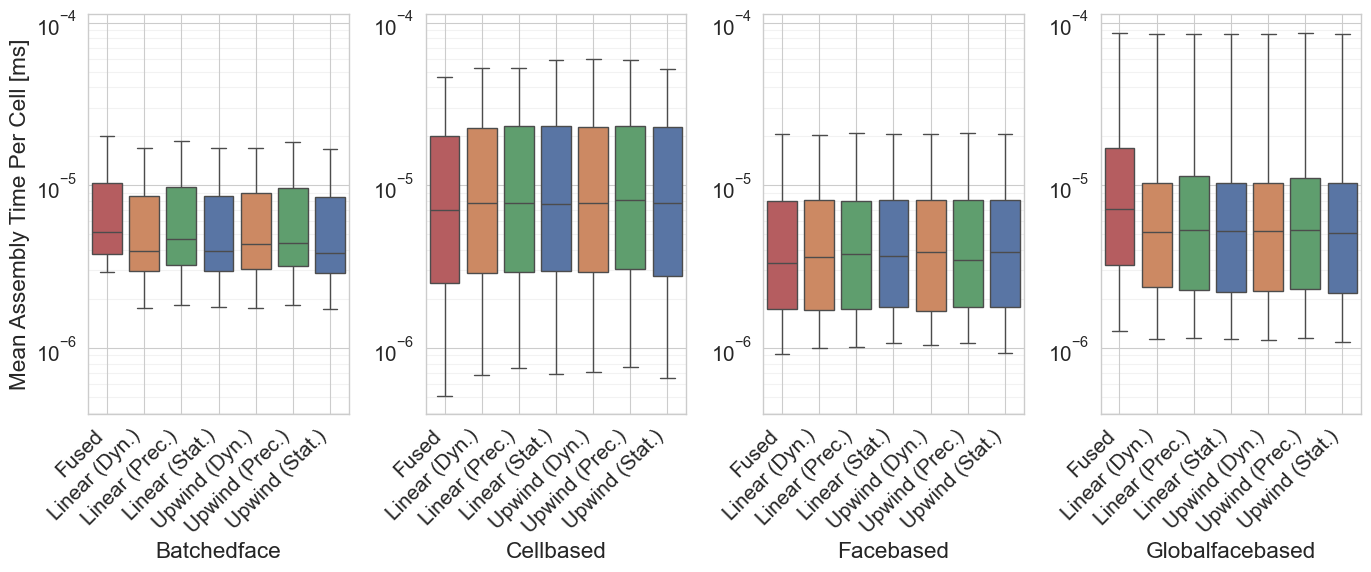

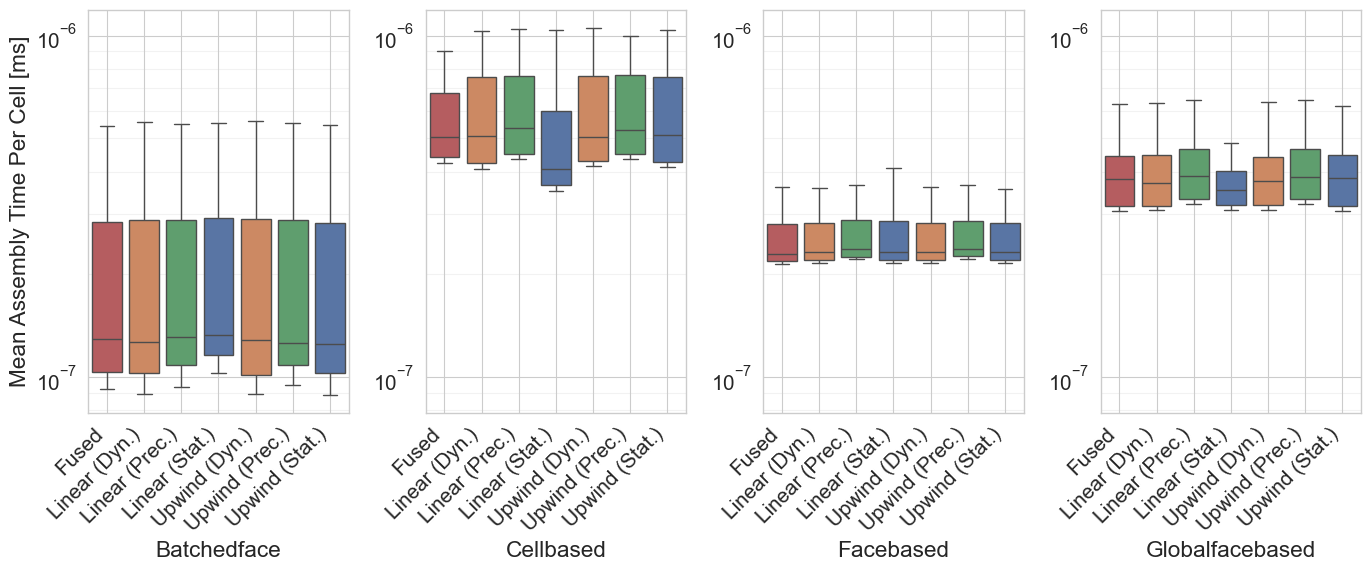

In [122]:

def variants(_df, name, plotname):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        strategies = sorted(_df["strategy"].unique()) 
        fig, axes = plt.subplots(1,len(strategies), figsize=(len(strategies)*3.5,6), sharey=True)
        for i, ax in enumerate(axes.flat):
            strat = strategies[i]
            case_df = _df[_df["strategy"] == strat]
            plot = sb.boxplot(data=case_df, ax=ax, x="varDisplay", y="ms_normed", log_scale=False, hue="varType", legend=False, showfliers=False, order=sorted_variants)
            plot.set_xticklabels(plot.get_xticklabels(), 
                                rotation=45, 
                                horizontalalignment='right'
            )
            plot.set(
                ylabel="Mean Assembly Time Per Cell [ms]",
            )
            plot.set(xlabel=f"{strat.capitalize()}")
            ax.yaxis.set_tick_params(labelleft=True)
            ax.set_yscale("log")
            # ax.yaxis.set_minor_locator(LogLocator(base=10, subs=(2, 3, 4, 5, 6, 7, 8, 9)))
            # ax.yaxis.set_minor_formatter(NullFormatter())
            ax.grid(True, which="major", axis="y")
            ax.grid(True, which="minor", axis="y", alpha=0.25)
            ax.grid(True, which="major", axis="x")
        plt.tight_layout()
        plt.savefig(f"variants_{name}_{plotname}.svg")
variants(serial, "cpu", "serial")
variants(cpu[cpu["Threads"]>1], "cpu", "multithread")
variants(df, "gpu", "")



/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

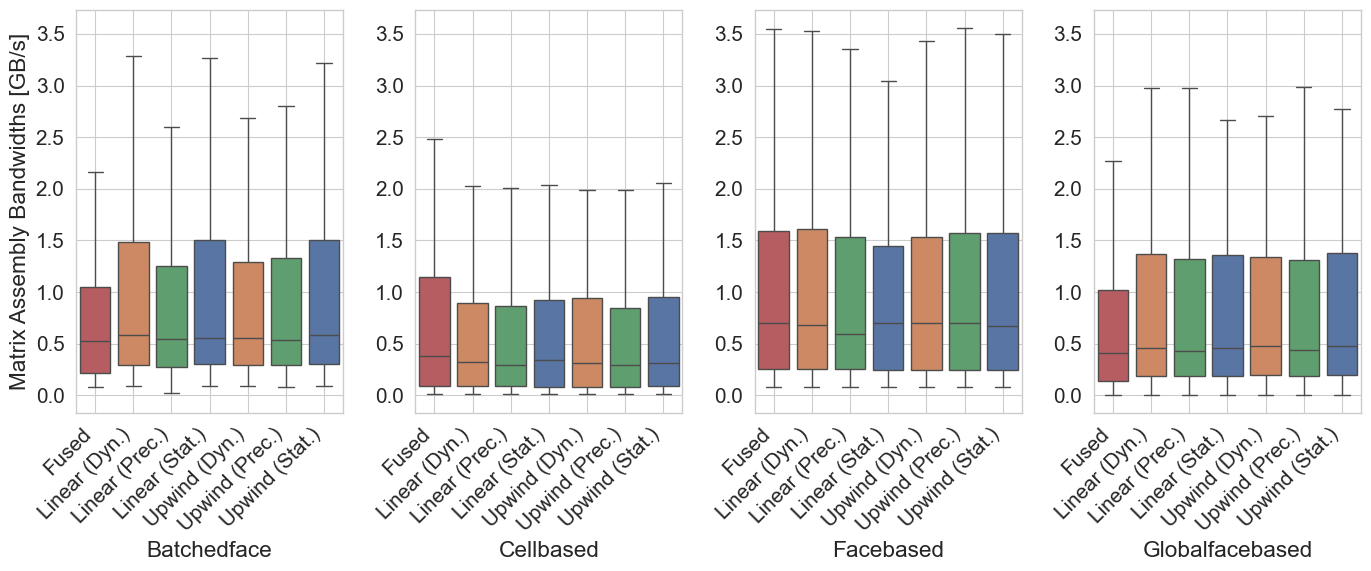

In [123]:

def variants_bw(_df, name, plotname):
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    with sb.plotting_context("paper", font_scale=1.7):
        strategies = sorted(_df["strategy"].unique()) 
        fig, axes = plt.subplots(1,len(strategies), figsize=(len(strategies)*3.5,6), sharey=True)
        for i, ax in enumerate(axes.flat):
            strat = strategies[i]
            case_df = _df[_df["strategy"] == strat]
            plot = sb.boxplot(data=case_df, ax=ax, x="varDisplay", y="bandwidth", log_scale=False, hue="varType", legend=False, showfliers=False, order=sorted_variants)
            plot.set_xticklabels(plot.get_xticklabels(), 
                                rotation=45, 
                                horizontalalignment='right'
            )
            plot.set(
                ylabel="Matrix Assembly Bandwidths [GB/s]",
            )
            plot.set(xlabel=f"{strat.capitalize()}")
            ax.yaxis.set_tick_params(labelleft=True)
            ax.grid(True)
            # ax.set_yscale("log")
        plt.tight_layout()
        # plt.savefig(f"variants_{name}_gpu.svg")
variants_bw(cpu, "cpu", "parallel")


writing into normed_gpu.svg


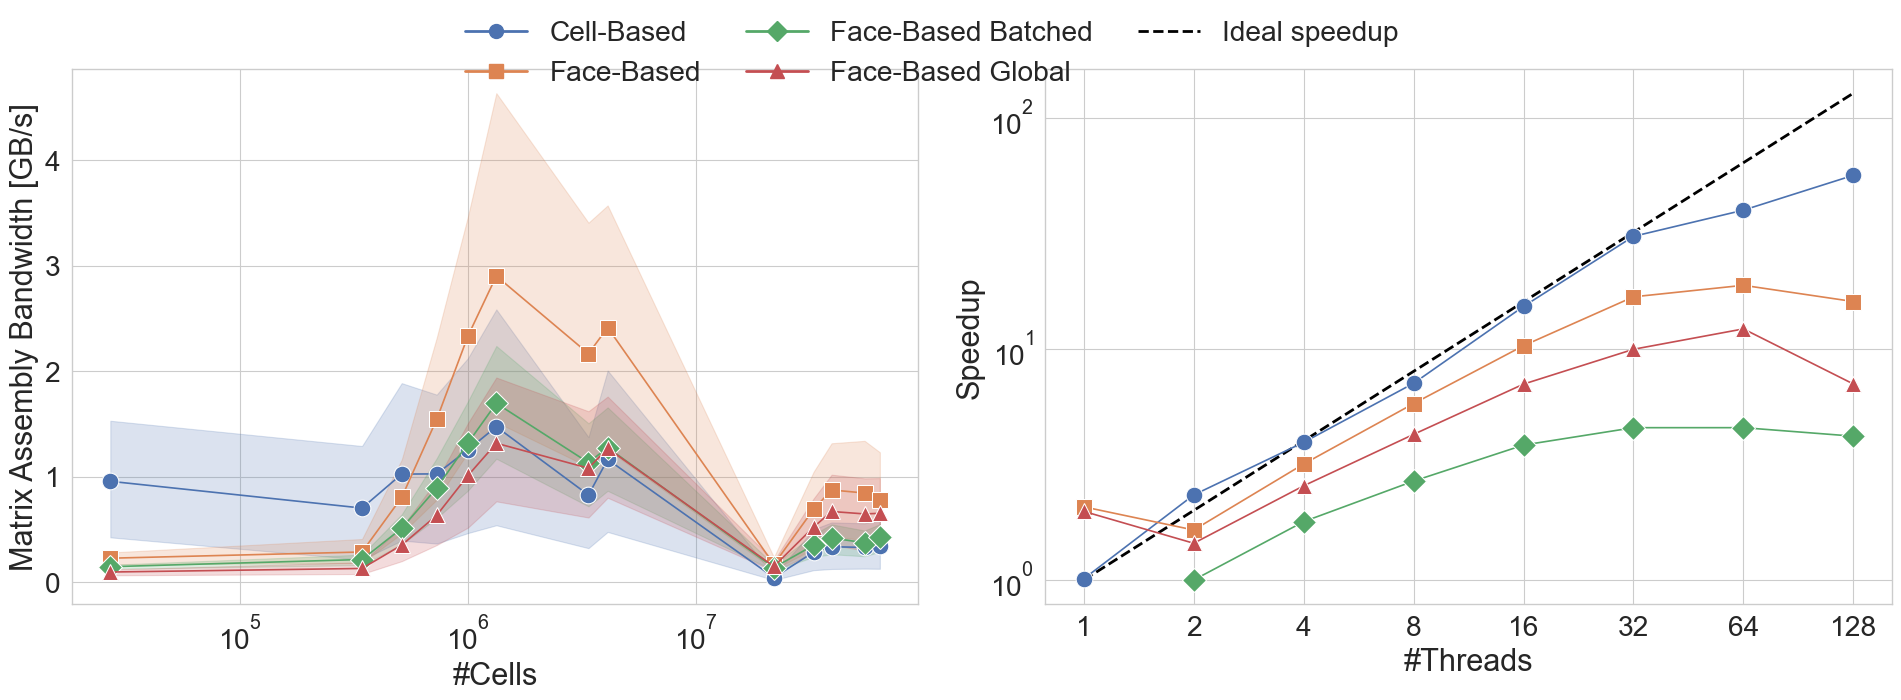

In [124]:

def normed_speedup(_df):
    # _df["dims"] = _df["cells"].apply(lambda x: int(x**(1/3)))
    # dims = sorted(_df["dims"].unique())
    sb.set_theme(rc={'figure.figsize':(20, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    order = sorted(_df["s_display"].unique())
    palette = dict(zip(order, sb.color_palette("deep", n_colors=len(order))))
    marker_symbols = ["o", "s", "D", "^", "v", "P", "X", "*"]
    markers = {strategy: marker_symbols[i % len(marker_symbols)] for i, strategy in enumerate(order)}
    plot_df = _df.copy()
    thread_values = sorted(plot_df["Threads"].dropna().unique())
    thread_positions = {thread: i for i, thread in enumerate(thread_values)}
    plot_df["thread_pos"] = plot_df["Threads"].map(thread_positions)
    
    with sb.plotting_context("paper", font_scale=2.3):
        fig, a= plt.subplots(1, 2)
        axes = a.flat

        p = sb.lineplot(
            data=plot_df,
            x="cells",
            y="bandwidth",
            hue="s_display",
            style="s_display",
            markersize=12,
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            # err_style=None,
            dashes=False,
            ax=axes[0]
        )
        p.set(
            ylabel="Matrix Assembly Bandwidth [GB/s]",
            xlabel="#Cells",
            # yscale="log",
            xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        p = sb.lineplot(
            data=plot_df,
            x="thread_pos",
            y="speedup",
            hue="s_display",
            style="s_display",
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            err_style=None,
            markersize=12,
            dashes=False,
            ax=axes[1]
        )
        p.set(
            ylabel="Speedup",
            xlabel="#Threads",
            yscale="log",
            # xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        p.set_xticks(list(thread_positions.values()))
        p.set_xticklabels([str(int(thread)) for thread in thread_values])
        p.plot(
            list(thread_positions.values()),
            thread_values,
            color="black",
            linestyle="--",
            linewidth=2,
            label="Ideal speedup",
            zorder=1,
        )
        handles = [Line2D([0], [0], color=palette[strategy], marker=markers[strategy], linestyle="-", markersize=10, linewidth=2, label=strategy) for strategy in order]
        handles.append(Line2D([0], [0], color="black", linestyle="--", linewidth=2, label="Ideal speedup"))
        labels = order + ["Ideal speedup"]
        for ax in axes:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        # # One shared legend above all subplots, 4 columns
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=3,
            columnspacing=1.6,
            handlelength=2.2,
            # title="Fused Strategy",
            frameon=False,
        )
        # plt.tight_layout()
        fig.subplots_adjust(
            left=0.07,
            right=0.98,
            # bottom=0.18,
            top=0.875,
            wspace=0.15,
        )
        print(f"writing into normed_gpu.svg")
        plt.savefig(f"bandwidth-speedup.svg")

normed_speedup(cpu[cpu["variant"] == "Fused"])

# normed(df[df["variant"] == "Fused"])


In [125]:
cpu["cells"].unique()

array([ 1000000,   343000,  3375000, 39304000,   512000,  4096000,
         729000,  1331000, 54872000, 32768000, 64000000,    27000,
       21952000])

writing into normed_gpu.svg
writing into normed_gpu.svg


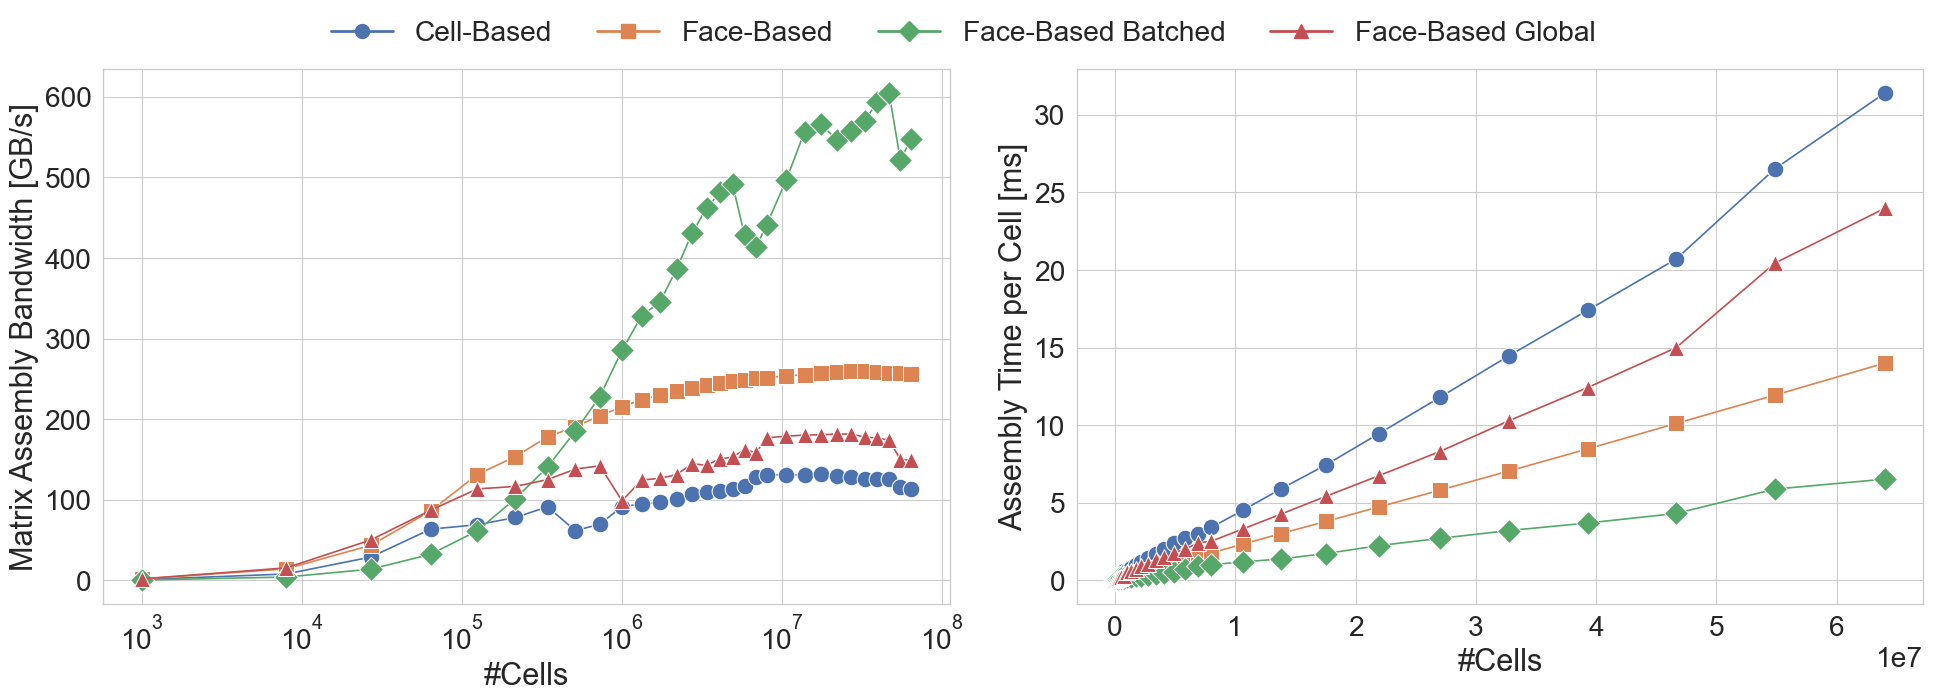

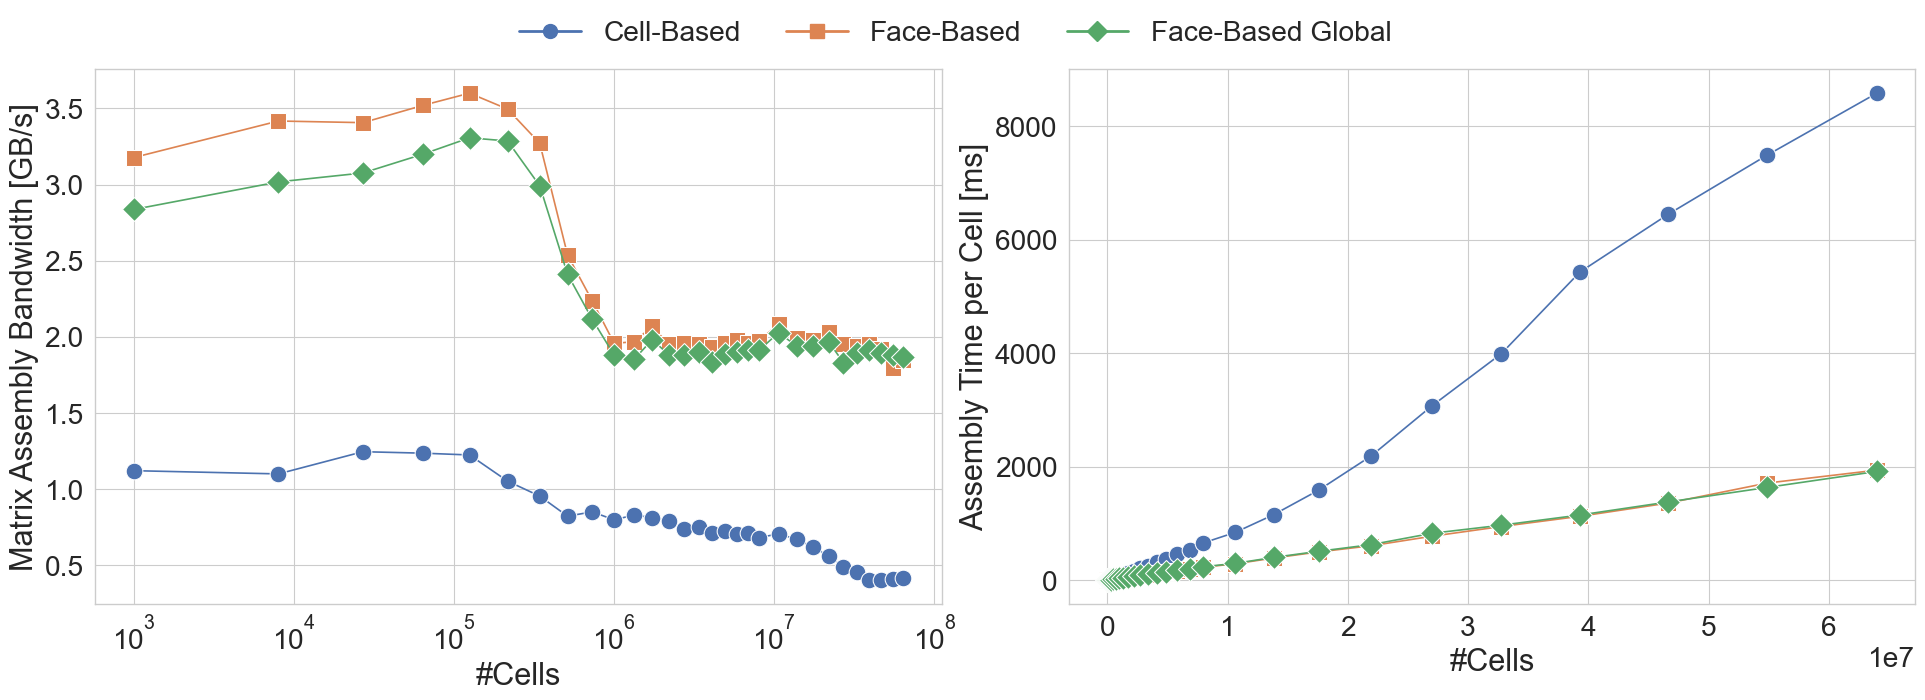

In [126]:

def normed(_df):
    # _df["dims"] = _df["cells"].apply(lambda x: int(x**(1/3)))
    # dims = sorted(_df["dims"].unique())
    sb.set_theme(rc={'figure.figsize':(20, 7)})
    sb.set_style("whitegrid")
    sb.color_palette("deep", 8)
    order = sorted(_df["s_display"].unique())
    palette = dict(zip(order, sb.color_palette("deep", n_colors=len(order))))
    marker_symbols = ["o", "s", "D", "^", "v", "P", "X", "*"]
    markers = {strategy: marker_symbols[i % len(marker_symbols)] for i, strategy in enumerate(order)}
    exec = list(_df["executor"].unique())[0]
    suffix = ""
    if exec == "cpu":
        if len(_df["Threads"].unique()) > 1:
            suffix = "-multithreaded"
        else:
            suffix = "-serial"
    with sb.plotting_context("paper", font_scale=2.3):
        fig, a= plt.subplots(1, 2)
        axes = a.flat

        p = sb.lineplot(
            data=_df,
            x="cells",
            y="bandwidth",
            hue="s_display",
            style="s_display",
            markersize=12,
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            err_style=None,
            dashes=False,
            ax=axes[0]
        )
        p.set(
            ylabel="Matrix Assembly Bandwidth [GB/s]",
            xlabel="#Cells",
            # yscale="log",
            xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        p = sb.lineplot(
            data=_df,
            x="cells",
            y="time_mean_ms",
            hue="s_display",
            style="s_display",
            hue_order=order,
            style_order=order,
            palette=palette,
            markers=markers,
            markersize=12,
            dashes=False,
            ax=axes[1]
        )
        p.set(
            ylabel="Assembly Time per Cell [ms]",
            xlabel="#Cells",
            # yscale="log",
            # xscale="log",
            # xticks=dims,
            # xticklabels=sorted(_df["cells"].unique())
            # xscale="log",
        )
        handles = [Line2D([0], [0], color=palette[strategy], marker=markers[strategy], linestyle="-", markersize=10, linewidth=2, label=strategy) for strategy in order]
        labels = order
        for ax in axes:
            leg = ax.get_legend()
            if leg is not None:
                leg.remove()

        # # One shared legend above all subplots, 4 columns
        fig.legend(
            handles,
            labels,
            loc="upper center",
            bbox_to_anchor=(0.5, 0.98),
            ncol=4,
            columnspacing=1.6,
            handlelength=2.2,
            # title="Fused Strategy",
            frameon=False,
        )
        # plt.tight_layout()
        fig.subplots_adjust(
            left=0.07,
            right=0.98,
            # bottom=0.18,
            top=0.875,
            wspace=0.15,
        )
        print(f"writing into normed_gpu.svg")
        plt.savefig(f"bandwidt-timenormed-{exec}{suffix}.svg")

# normed(cpu[(cpu["variant"] == "Fused")& (cpu["Threads"]> 1)])

normed(df[df["variant"] == "Fused"])
# normed(serial[(serial["variant"] == "Fused") & (serial["cells"] <= 1000000)])
normed(serial[(serial["variant"] == "Fused")])


writing into normed_gpu.svg


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/2458882214.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

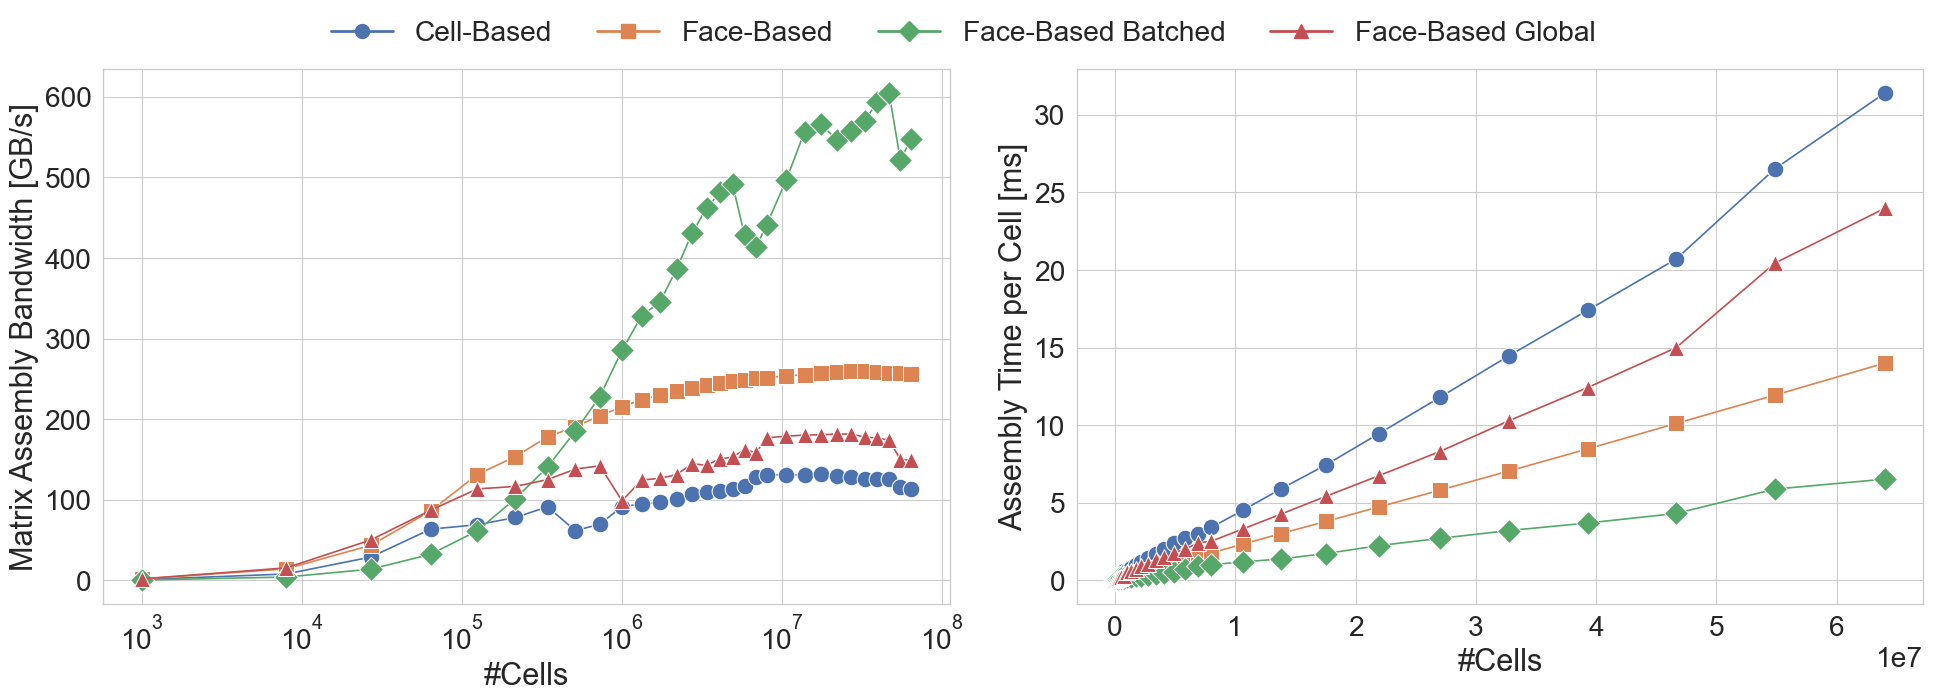

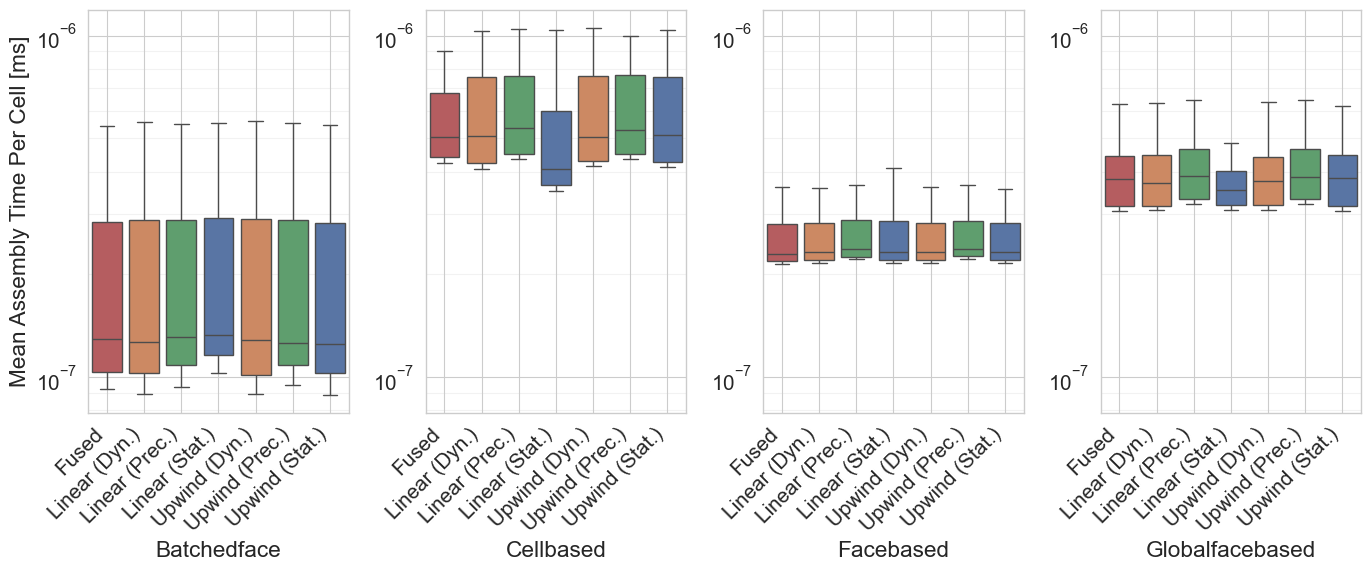

In [127]:

normed(df[df["variant"] == "Fused"])

variants(df, "gpu", "GPU")
# batched = df[df["strategy"] == "batchedFace"]
# batched = batched[batched["variant"] == "Fused"]
# batched.to_csv("batched.csv", index=False)


writing into normed_gpu.svg
writing into normed_gpu.svg


/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xticklabels(plot.get_xticklabels(),
/var/folders/h5/6j3mwzw54mj68r1hrzzgsm9r0000gn/T/ipykernel_45385/4207787416.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  plot.set_xtic

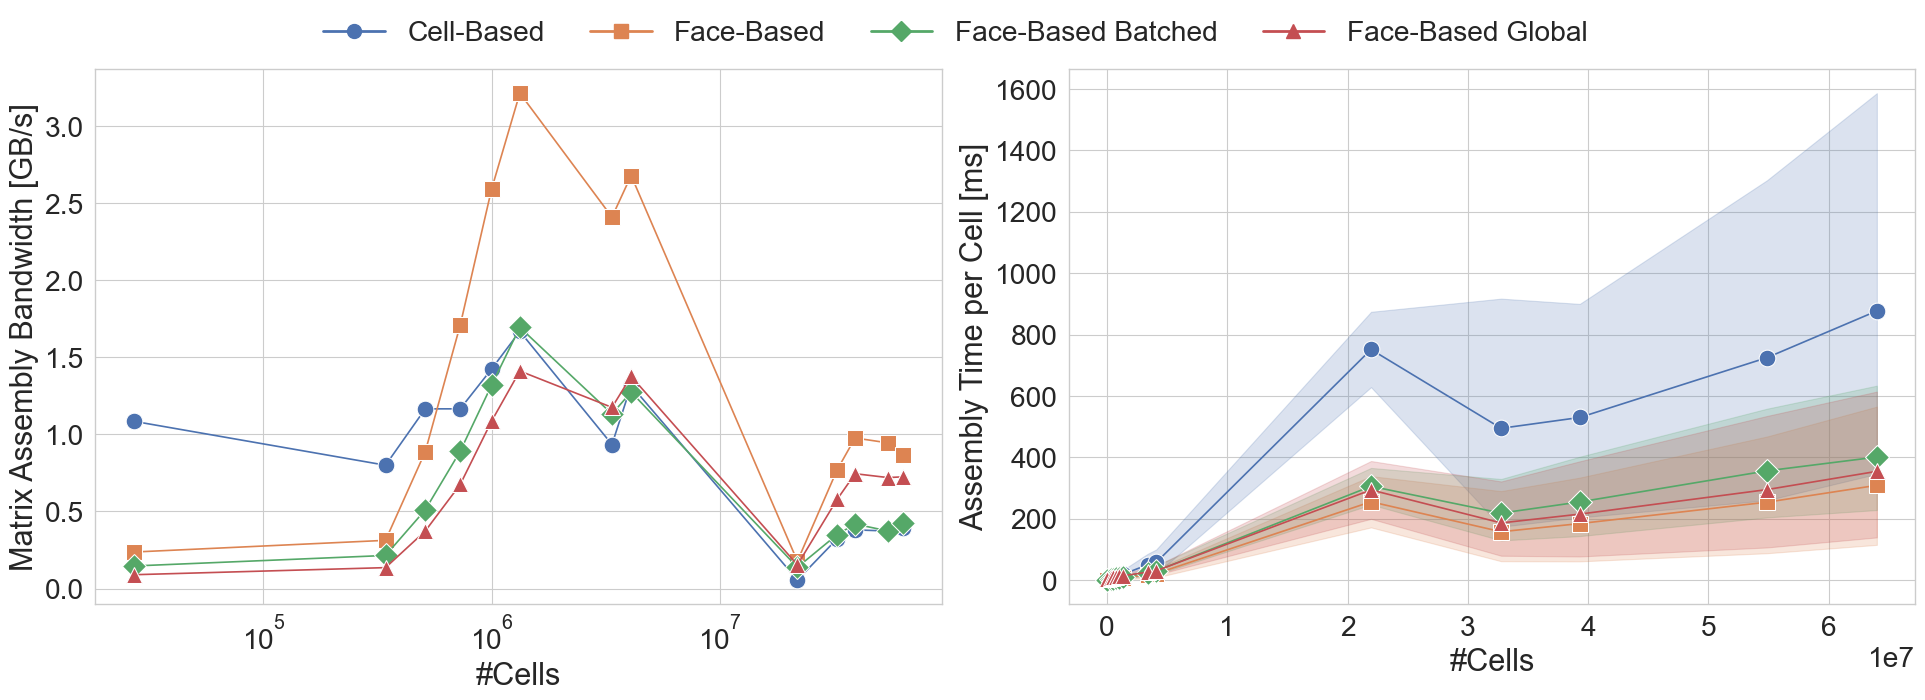

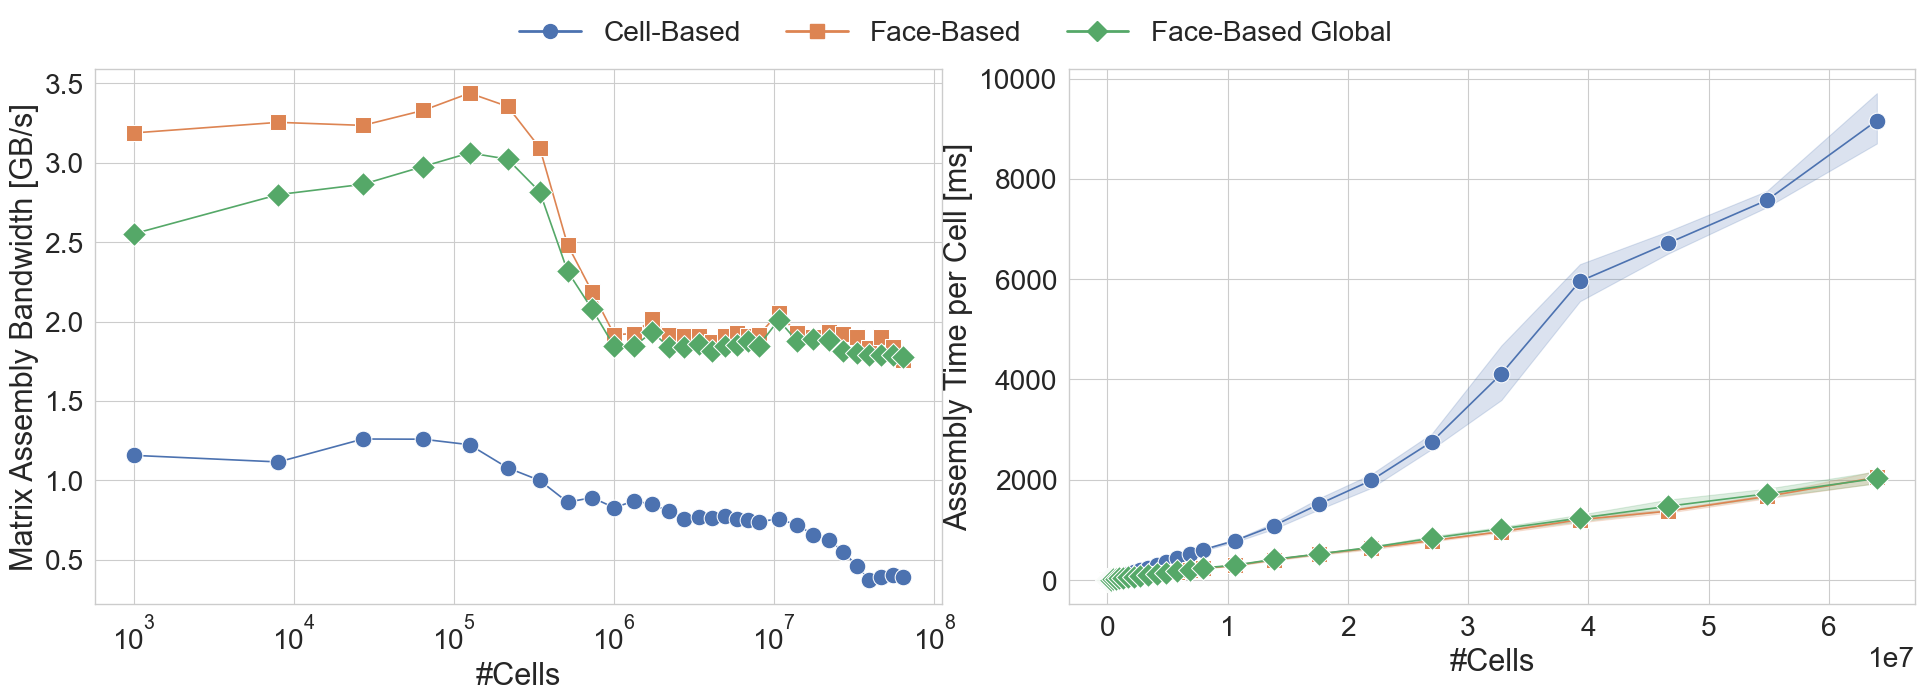

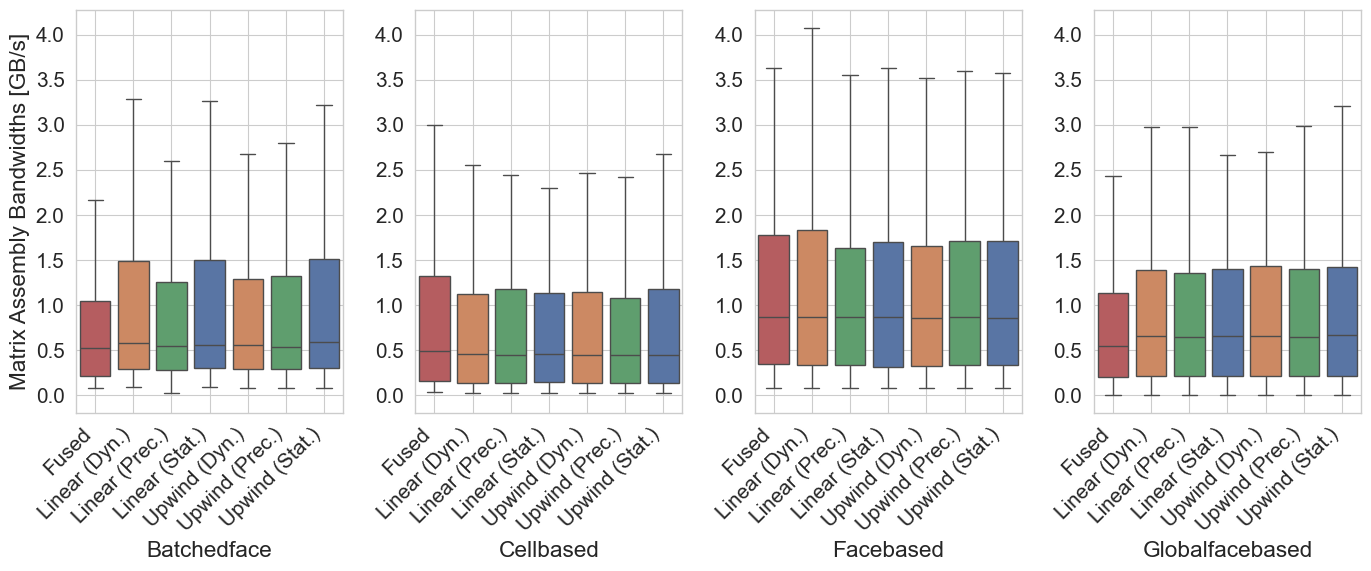

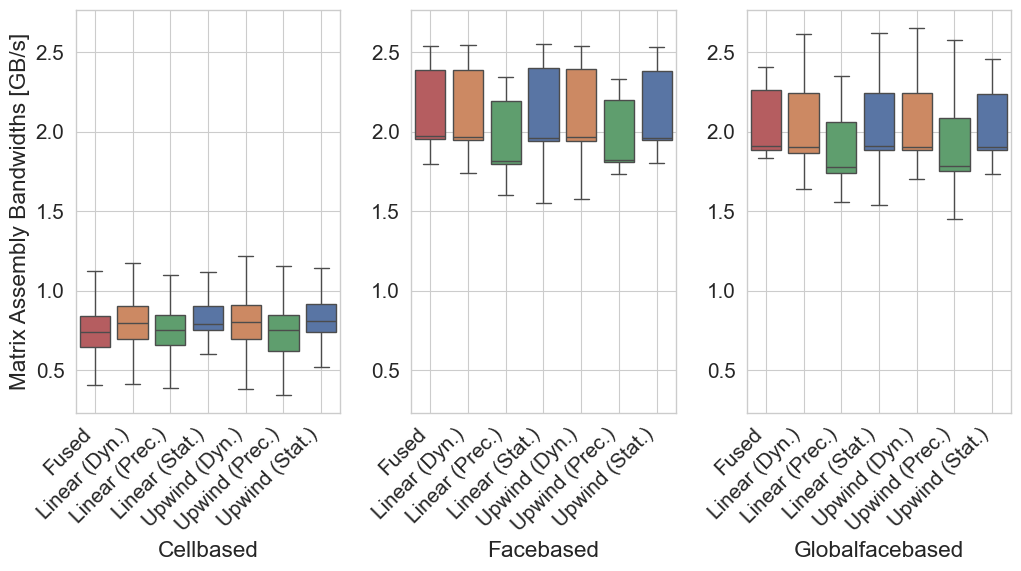

In [128]:
normed(cpu[(cpu["variant"] == "Fused")& (cpu["Threads"]> 1)])
normed(serial)
variants_bw(cpu[cpu["Threads"]> 1], "cpu", "parallel")
variants_bw(serial, "cpu", "serial")
